# Next Character Prediction Using MLP Cont'd

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
# read the dataset (names.txt)
words = open('names.txt', 'r').read().splitlines()

In [4]:
chars = sorted(list(set('.abcdefghijklmnopqrstuvwxyz')))
chartoi = {s:i for i, s in enumerate(chars)}
itochar = {i:s for s,i in chartoi.items()}

In [7]:
# build the dataset

BLOCK_SIZE = 3 # Defines the context length ie. how many characters to use to predict the next one
X, Y = [], []

for w in words:
    #print(w)
    context = [0] * BLOCK_SIZE
    for ch in w + '.':
        idx = chartoi[ch]
        X.append(context)
        Y.append(idx)
        #print(f"{"".join(itochar[c] for c in context)} --> {ch}")
        context = context[1:] + [idx] # pop and push

X = torch.tensor(X)
Y = torch.tensor(Y)

In [9]:
# split the data into training, validation, and test set

N = X.shape[0] 
n_train = int(0.8 * N)
n_val = int(0.1 * N)
# n_test is whatever is left over

indices = torch.randperm(N)

train_indices = indices[:n_train]
val_indices = indices[n_train : n_train + n_val]
test_indices = indices[n_train + n_val:]

X_train, Y_train = X[train_indices], Y[train_indices]
X_val, Y_val = X[val_indices], Y[val_indices]
X_test, Y_test = X[test_indices], Y[test_indices]

print(f"Train: {X_train.shape}, {Y_train.shape}")
print(f"Val:   {X_val.shape}, {Y_val.shape}")
print(f"Test:  {X_test.shape}, {Y_test.shape}")

Train: torch.Size([182516, 3]), torch.Size([182516])
Val:   torch.Size([22814, 3]), torch.Size([22814])
Test:  torch.Size([22816, 3]), torch.Size([22816])


In [13]:
class MLP:

    def __init__(self, block_size=3, embedding_dimensions=10, hidden_layer_size=200, output_layer_size=len(chars)):
        self.EMBEDDING_DIMENSIONS = embedding_dimensions # the dimensionality of the embedding space
        self.HIDDEN_LAYER_SIZE = hidden_layer_size # number of neurons in hidden layer
        self.OUTPUT_LAYER_SIZE = output_layer_size # number of neurons in output layer
        self.BLOCK_SIZE = block_size # context window length

        # initialize weights
        g = torch.Generator().manual_seed(2147483647) # for reproducibility
        self.C = torch.randn((len(chars), self.EMBEDDING_DIMENSIONS), requires_grad=True, generator=g)
        self.W1 = torch.randn((self.BLOCK_SIZE * self.EMBEDDING_DIMENSIONS, self.HIDDEN_LAYER_SIZE), requires_grad=True, generator=g)
        #self.W1.data *= 0.1 # scale down to keep tanh gradient non-zero
        self.b1 = torch.randn(self.HIDDEN_LAYER_SIZE, requires_grad=True, generator=g)
        #self.b1.data *= 0.01 # scale down to keep tanh gradient non-zero

        # bias and gain for batch normalization
        self.bngain = torch.ones((1, self.HIDDEN_LAYER_SIZE), requires_grad=True)
        self.bnbias = torch.zeros((1, self.HIDDEN_LAYER_SIZE), requires_grad=True)
        
        self.W2 = torch.randn((self.HIDDEN_LAYER_SIZE, self.OUTPUT_LAYER_SIZE), requires_grad=True, generator=g) 
        self.W2.data *= 0.001 # init small vals for even distribution
        self.b2 = torch.randn(self.OUTPUT_LAYER_SIZE, requires_grad=True, generator=g) 
        self.b2.data *= 0.0 # init to zeros
        self.parameters = [self.C, self.W1, self.b1, self.W2, self.b2, self.bngain, self.bnbias]

    def _compute_hidden_layer_activations(self, X):
        emb = self.C[X] # map inp chars to embeddings

        X1_preactivation = (emb.flatten(start_dim=1) @ self.W1) + self.b1 # apply linear transformation

        # apply batch normalization
        X1_preactivation = self.bngain * (X1_preactivation - X1_preactivation.mean(0, keepdim=True)) / X1_preactivation.std(0, keepdim=True) + self.bnbias

        X1 = F.tanh(X1_preactivation) # apply non-linear activation
        
        return X1
    
    # forward pass through the MLP and return logits
    def _compute_logits(self, X):
        emb = self.C[X] # map inp chars to embeddings
        
        X1_preactivation = (emb.flatten(start_dim=1) @ self.W1) + self.b1 # apply linear transformation fr hidden layer

        # apply batch normalization
        X1_preactivation = self.bngain * (X1_preactivation - X1_preactivation.mean(0, keepdim=True)) / X1_preactivation.std(0, keepdim=True) + self.bnbias
        
        X1 = F.tanh(X1_preactivation) # apply non-linear activation
        
        logits = (X1 @ self.W2) + self.b2 # apply linear pre-activation for output layer
        
        return logits

    # forward pass throught MLP and return next char probs
    def forward(self, X):
        probs = F.softmax(self._compute_logits(X), dim=1) # apply softmax to output layer pre-activations
        return probs

    # do a forward pass and compute cross-entropy loss (wrt. actual labels)
    def forward_and_compute_loss(self, X, Y):
        loss = F.cross_entropy(self._compute_logits(X), Y)
        return loss

    # zero grads all the weights in the MLP
    def zero_grad(self):
        for p in self.parameters:
            p.grad = None

    # update weights based on their calculated gradients
    def update_weights(self, learning_rate):
        for p in self.parameters:
            p.data += -learning_rate * p.grad

In [14]:
mlp = MLP()

In [15]:
# ideal expected initial loss:

ideal_probs = F.softmax(torch.ones((X.shape[0], len(chars))) * (1/27.0), dim=1)
ideal_loss = F.cross_entropy(ideal_probs, Y)
print(ideal_loss)

# actual initial loss:

mlp.forward_and_compute_loss(X, Y)

tensor(3.2958)


tensor(3.2965, grad_fn=<NllLossBackward0>)

(array([207., 286., 294., 282., 229., 256., 231., 215., 213., 197., 223.,
        222., 193., 133., 165., 147., 164., 157., 166., 158., 148., 118.,
        164., 132., 162., 124., 126., 144., 131., 146., 154., 139., 143.,
        145., 169., 145., 142., 189., 194., 182., 211., 200., 216., 258.,
        230., 245., 307., 296., 277., 225.]),
 array([-9.97823834e-01, -9.57922281e-01, -9.18020728e-01, -8.78119174e-01,
        -8.38217621e-01, -7.98316067e-01, -7.58414514e-01, -7.18512961e-01,
        -6.78611407e-01, -6.38709854e-01, -5.98808300e-01, -5.58906747e-01,
        -5.19005194e-01, -4.79103640e-01, -4.39202087e-01, -3.99300534e-01,
        -3.59398980e-01, -3.19497427e-01, -2.79595873e-01, -2.39694320e-01,
        -1.99792767e-01, -1.59891213e-01, -1.19989660e-01, -8.00881064e-02,
        -4.01865530e-02, -2.84999609e-04,  3.96165538e-02,  7.95181072e-02,
         1.19419661e-01,  1.59321214e-01,  1.99222767e-01,  2.39124321e-01,
         2.79025874e-01,  3.18927428e-01,  3.58828

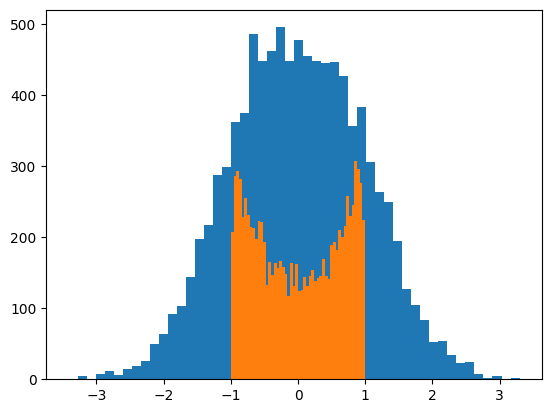

In [205]:
# plot initial tanh
ix = torch.randint(0, X_train.shape[0], (32,))
X1 = mlp._compute_hidden_layer_activations(X[ix])
plt.hist(X1.view(-1).tolist(), 50)
plt.hist(F.tanh(X1).view(-1).tolist(), 50)

Training loss at epoch 0: 3.2978591918945312
Training loss at epoch 10000: 3.0825090408325195
Training loss at epoch 20000: 2.932847023010254
Training loss at epoch 30000: 2.9139039516448975
Training loss at epoch 40000: 2.828564405441284
Training loss at epoch 50000: 2.9102137088775635
Training loss at epoch 60000: 2.617321729660034
Training loss at epoch 70000: 3.070721387863159
Training loss at epoch 80000: 2.7152228355407715
Training loss at epoch 90000: 2.8176543712615967
Training loss at epoch 100000: 2.4779486656188965
Training loss at epoch 110000: 2.908785820007324
Training loss at epoch 120000: 2.568211555480957
Training loss at epoch 130000: 2.7307872772216797
Training loss at epoch 140000: 2.7212295532226562
Training loss at epoch 150000: 2.5784621238708496
Training loss at epoch 160000: 2.696993827819824
Training loss at epoch 170000: 2.5408592224121094
Training loss at epoch 180000: 2.274466037750244
Training loss at epoch 190000: 2.33667254447937
---Training complete---


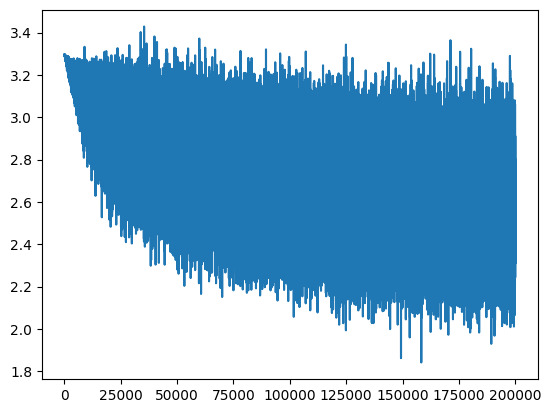

In [16]:
# train the MLP

EPOCHS = 200000
LEARNING_RATE = 0.0001
MINI_BATCH_SIZE = 32

lossi = []
stepi = []

for e in range(EPOCHS):
    # construct mini-batch
    ix = torch.randint(0, X_train.shape[0], (MINI_BATCH_SIZE,))
    
    loss = mlp.forward_and_compute_loss(X_train[ix], Y_train[ix])

    stepi.append(e)
    lossi.append(loss.item())
    
    mlp.zero_grad()
    loss.backward()

    mlp.update_weights(LEARNING_RATE)

    if e % 10000 == 0:
        print(f"Training loss at epoch {e}: {loss.item()}")

print(f"---Training complete---")
print(f"Final loss: {mlp.forward_and_compute_loss(X_train, Y_train).item()}")

plt.plot(stepi, lossi)

In [41]:
# evaluating model on the validation set

print(f"Loss on validation set: {mlp.forward_and_compute_loss(X_val, Y_val).item()}")

Loss on validation set: 2.255812883377075


In [99]:
# generate new names using the MLP model

for i in range(1, 6):
    generated_name = "..."
    while True:
        x = torch.tensor([[chartoi[ch] for ch in generated_name[-3:]]])
        output_probs = mlp.forward(x)
        next_char_i = torch.multinomial(output_probs, num_samples=1, replacement=True).item()
        next_char = itochar[next_char_i]
        if next_char == ".":
            break
        generated_name += next_char
    print(f"Generated name {i}: {generated_name[3:]}")

Generated name 1: 
Generated name 2: anna
Generated name 3: ley
Generated name 4: cher
Generated name 5: elaniel


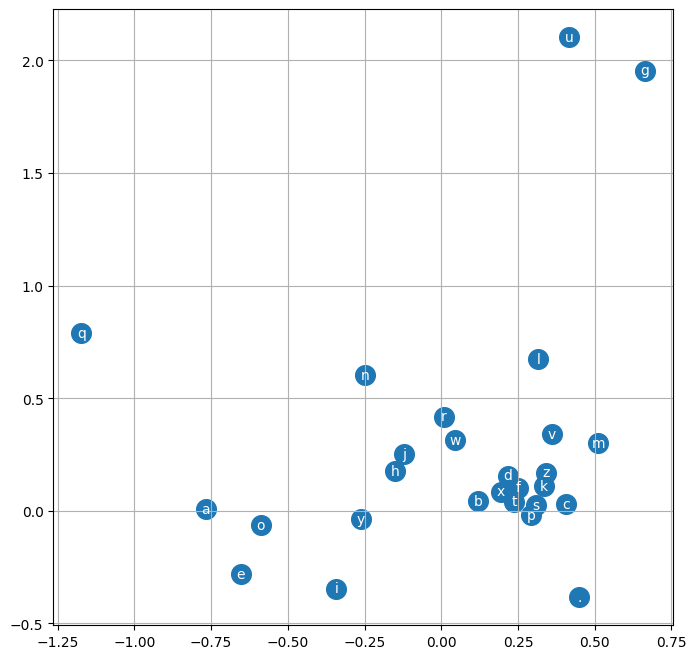

In [82]:
# visualize the embeddings

plt.figure(figsize=(8,8))
plt.scatter(mlp.C[:,0].data, mlp.C[:,1].data, s=200)
for i in range(mlp.C.shape[0]):
    plt.text(mlp.C[i,0].item(), mlp.C[i,1].item(), itochar[i], ha="center", va="center", color='white')
plt.grid('minor')